<a href="https://colab.research.google.com/github/Sultoniromadhon/data-science-2026/blob/main/Pertemuan7_Sultoni_Romadhon_250401020198.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
# Generate dataset sintetis

np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)

# 0=SMA, 1=D3, 2=S1
edu = np.random.choice([0, 1, 2], n)

kota = np.random.choice(
    ['Jakarta', 'Surabaya', 'Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

df.head()

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [83]:
print("Shape:", df.shape)

print("\nDeskripsi Statistik:")
print(df.describe().round(2))

Shape: (300, 4)

Deskripsi Statistik:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


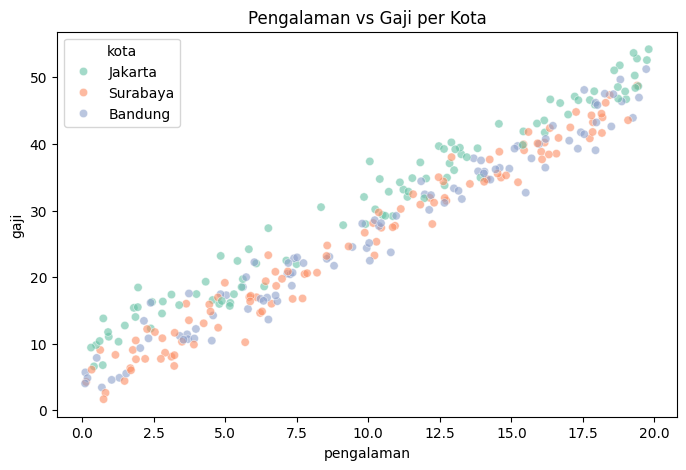

In [84]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title('Pengalaman vs Gaji per Kota')
plt.show()

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [86]:
df_encoded = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding:")
print(df_encoded.columns.tolist())

df_encoded.head()

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [87]:
X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

print("Fitur:")
print(X.columns.tolist())

Fitur:
['pengalaman', 'edu', 'kota_Jakarta', 'kota_Surabaya']


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

Train: 240 baris
Test : 60 baris


In [89]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Scaling selesai")

Scaling selesai


In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_s, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [91]:
print(f"β₀ (Intercept) = {model.intercept_:.3f}")

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
})

coef_df = coef_df.sort_values(
    by='Koefisien',
    ascending=False
)

coef_df

β₀ (Intercept) = 27.514


,Fitur,Koefisien
0,pengalaman,13.042241
2,kota_Jakarta,1.837226
1,edu,1.187879
3,kota_Surabaya,-0.291561


In [92]:
y_pred = model.predict(X_test_s)

print("5 Prediksi Pertama:")
print(y_pred[:5])

5 Prediksi Pertama:
[42.89380034 36.87384692 10.5713704  37.35990762 31.73594551]


In [93]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("=== Metrik Evaluasi ===")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.4f}")
print(f"Selisih RMSE-MAE = {rmse-mae:.3f}")

=== Metrik Evaluasi ===
MAE  = 1.649
RMSE = 2.123
R²   = 0.9740
Selisih RMSE-MAE = 0.474


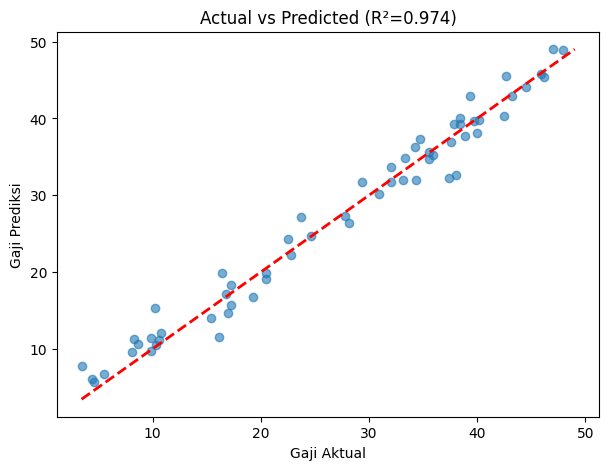

In [94]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2
)

plt.xlabel('Gaji Aktual')
plt.ylabel('Gaji Prediksi')
plt.title(f'Actual vs Predicted (R²={r2:.3f})')

plt.show()

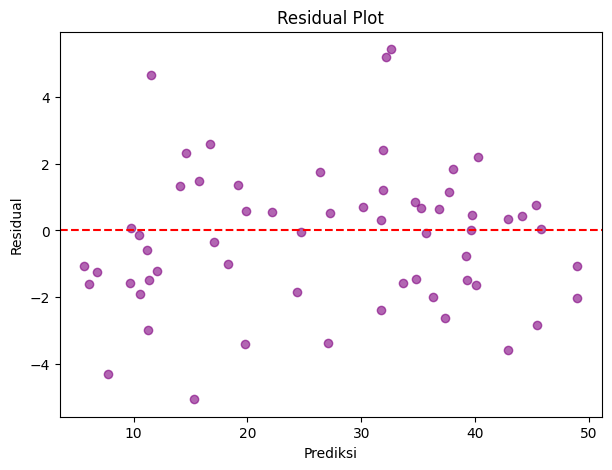

In [95]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color='purple'
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Prediksi')
plt.ylabel('Residual')

plt.title('Residual Plot')

plt.show()

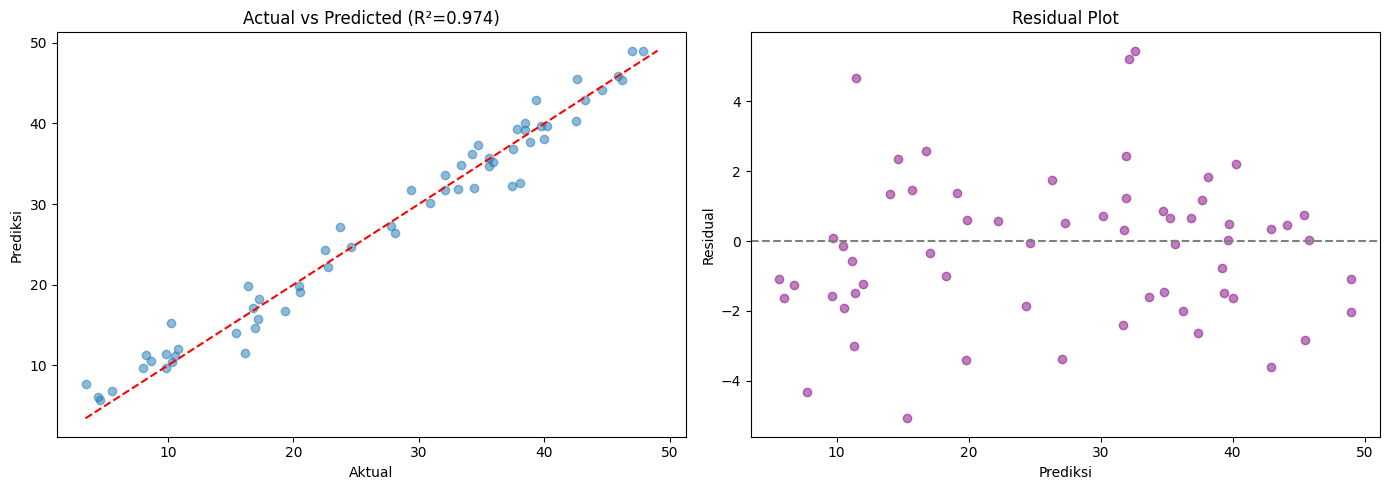

In [96]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5
)

axes[0].plot(
    lims,
    lims,
    'r--'
)

axes[0].set_title(
    f'Actual vs Predicted (R²={r2:.3f})'
)

axes[0].set_xlabel('Aktual')
axes[0].set_ylabel('Prediksi')

# Residual Plot
axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='purple'
)

axes[1].axhline(
    0,
    linestyle='--',
    color='gray'
)

axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Residual')

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()